# PM-BG-AES Demo (Colab-friendly)
Faithful demonstration of the archival implementation on synthetic data.

- Original notebooks (unmodified) live in `notebooks/original/`.
- Password below is **demonstration-only**, never a secret.
- In Google Colab: upload this notebook + install requirements, or `pip install pycryptodome psutil matplotlib` in a cell.
> These are new local demonstration measurements, not reproductions of the manuscript's original numerical results.

In [1]:
# On Colab, uncomment:
# !pip install pycryptodome psutil matplotlib
import sys, os
sys.path.insert(0, os.path.abspath('src'))
import numpy as np
from pm_bg_aes import *
print('pm_bg_aes', __import__('pm_bg_aes').__version__)

pm_bg_aes 0.1.0


## 1. Roundtrip on structured demo text (DEMO-004 scale class)

In [2]:
plain = open('data/demo/demo_004_structured_text.txt','rb').read()
pw = 'PMBG-AES-DEMO-2026'  # demonstration-only
mp = np.frombuffer(plain, dtype=np.uint8)
print('size', len(plain), 'entropy', round(float(shannon_entropy(mp)), 4))
blob, n, len_hill, len_shift = encrypt_bytes(plain, pw)
print('n =', n, '| len_hill =', len_hill, '| residual =', len_shift)
P, _ = key_matrix(n)
print('P[:6,:6] =\n', np.asarray(P)[:6,:6])
rec = decrypt_bytes(blob, pw)
print('recovered:', rec == plain, '| sha match:', sha256_bytes(rec) == sha256_bytes(plain))

size 5984 entropy 5.0439
n = 6 | len_hill = 5982 | residual = 2
P[:6,:6] =
 [[1 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 0 1 0]
 [0 0 0 1 0 0]
 [0 0 0 0 0 1]]
recovered: True | sha match: True


## 2. Selector across all demo datasets

In [3]:
import glob
for f in sorted(glob.glob('data/demo/*')):
    d = np.fromfile(f, dtype=np.uint8)
    print(f.split('/')[-1][:32].ljust(32), len(d), 'ent=%.4f' % shannon_entropy(d), 'n=', select_matrix_size(d))

demo_001_empty.bin               0 ent=0.0000 n= 4
demo_002_tiny.bin                37 ent=5.2095 n= 6
demo_003_repeated_byte.bin       6000 ent=-0.0000 n= 4
demo_004_structured_text.txt     5984 ent=5.0439 n= 6
demo_005_pseudorandom_100k.bin   100000 ent=7.9982 n= 12
demo_006_mixed_600k.bin          600000 ent=7.7395 n= 24
demo_007_archive.zip             486 ent=6.6016 n= 6
demo_008_pseudorandom_5m.bin     5200000 ent=8.0000 n= 48
demo_009_structured_100k.txt     100000 ent=5.0347 n= 8
demo_010_structured_600k.txt     600000 ent=5.0450 n= 16


demo_011_zeros_5m.bin            5200000 ent=-0.0000 n= 32


## 3. Byte histogram (original vs ciphertext, DEMO-005)

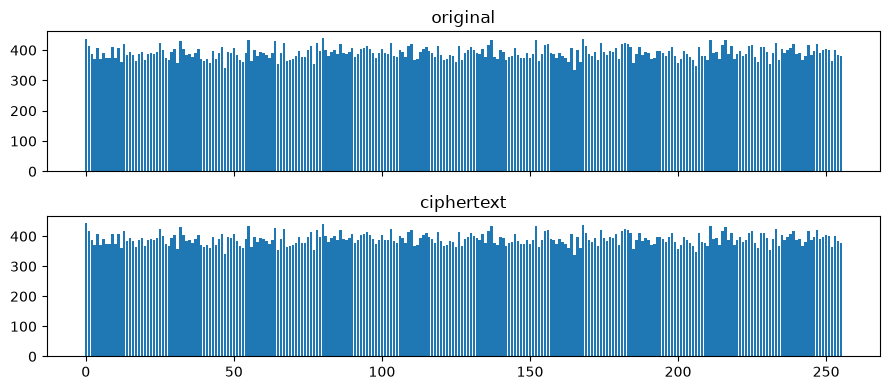

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
o = open('data/demo/demo_005_pseudorandom_100k.bin','rb').read()
c, *_ = encrypt_bytes(o, pw)
fig, ax = plt.subplots(2, 1, figsize=(9, 4), sharex=True)
ax[0].bar(range(256), np.bincount(np.frombuffer(o, dtype=np.uint8), minlength=256)); ax[0].set_title('original')
ax[1].bar(range(256), np.bincount(np.frombuffer(c, dtype=np.uint8), minlength=256)); ax[1].set_title('ciphertext')
plt.tight_layout(); plt.show()